# Customer Behavior Analysis — Telecom Dataset

<Col gap={2}><Row gap={3} align="center"><Badge label="Portfolio Project" color="info" variant="soft"/><Badge label="Data Analysis" color="secondary" variant="soft"/><Badge label="Python · Pandas · Matplotlib · Seaborn" color="secondary" variant="soft"/></Row><Title value="Customer Behavior Analysis — Telecom Dataset" size="2xl"/><Text color="secondary">A recruiter-ready version of the notebook focused on business questions, methodology, and findings. Academic instructions, grading prompts, and execution artifacts were removed.</Text></Col>

<Divider/>

<Title value="Business objective" size="lg"/><Text>Analyze customer behavior metrics to identify usage patterns, compare segments/plans, and surface insights that could inform retention, pricing, and engagement strategies.</Text>

<Title value="Dataset scope" size="lg"/><Text>The notebook works with a telecom customer-behavior dataset that includes usage indicators such as calls, messages, internet consumption, plan/category labels, and customer attributes. Exact column names remain unchanged from the original file.</Text>

<Title value="Methodology" size="lg"/><List marker="decimal" connector="solid"><List.Item>Load and inspect the dataset.</List.Item><List.Item>Assess data quality (missing values, duplicates, types, outliers).</List.Item><List.Item>Clean and standardize relevant fields.</List.Item><List.Item>Explore distributions and segment differences with descriptive statistics and visualizations.</List.Item><List.Item>Summarize business implications and limitations.</List.Item></List>

<Title value="Notebook structure" size="lg"/><List marker="decimal" connector="solid"><List.Item>Data loading &amp; overview</List.Item><List.Item>Data cleaning &amp; validation</List.Item><List.Item>Exploratory analysis</List.Item><List.Item>Segment/plan comparisons</List.Item><List.Item>Conclusions &amp; recommendations</List.Item></List>

<Title value="Repository presentation tips" size="lg"/><List marker="decimal" connector="solid"><List.Item>Keep the notebook free of execution artifacts (already applied).</List.Item><List.Item>Add a <Text inline weight="semibold" value="README.md"/> with a 5–8 line project summary, dataset source (if shareable), key findings, and a screenshot of one chart.</List.Item><List.Item>Include a short <Text inline weight="semibold" value="Requirements"/> section (Python version and main libraries).</List.Item><List.Item>If the dataset is not redistributable, provide only the notebook and a note explaining how to obtain the data.</List.Item></List>

<Divider/>

<Caption value="Prepared for portfolio/recruiter review. Remove or adapt any proprietary dataset references before publishing."/>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?

In [1]:

# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# cargar archivos
plans = pd.read_csv('https://drive.google.com/uc?export=download&id=17Mkcs9rRWwiC_gaqVBYuFieON7s9v7Bn')
users = pd.read_csv('https://drive.google.com/uc?export=download&id=17wuqxalUsUnw9PXvCN2_UaAz6xeS9B0T')
usage = pd.read_csv('https://drive.google.com/uc?export=download&id=11T8MQf-ouxJu9tia4F8aNpY7M_fb9O4h')


In [3]:
# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

In [6]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [8]:
# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**:podemos ver datos nulos o no validos en city que podriamos revisar pues puede ser algun fallo de escritura, tipo de dato invalido o que dejaron el espacio en blanco.
Los datos ausentes en duration y length son por el tipo de dato uno no puede ser constante por que las llamadas no no cuentan con texto

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: podemos ver que tenemos muchos valores faltantes o invialidos llegando hasta un 55% en duration por lo que podriamos dejarlos como nulos para evitar
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

In [12]:
# explorar columnas numéricas de users
print(users.describe())


            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` cuenta con valores bastante adecuados para un analisis y podemos hacerlo facilmente pues no cuenta con una infación de datos
- La columna `age` en esta debemos hacer revision pues tenemos datos imposibles como -999 y tambien tenemos std con mucho valor para la edad asi que tendremos que darle revision

In [13]:
# explorar columnas numéricas de usage
print(usage.describe())


                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` primero tenemos dos columna bastante adecuada con buena distribución para hacer un analisis 
- Las columnas `duration` y `length` cuentan con valores maximos incoherentes que inflan los datos hacia la derecha

In [14]:

# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].describe()

print(columnas_user)


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` tenemos aproximadamente 450 datos invalidos contando con la mayor concentración en Bogotá 
- La columna `plan` tenemos datos completos y povemos ver que poco mas del 50% de los clientes cuentan con el plan basico

In [15]:
# explorar columna categórica de usage
usage['type'].describe()


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` podemos notar que suelen ser mas la frecuencia de los mesajes que las llamadas pero la columna es totalmente usable a aun que registre tantos nulos debido a el tipo de la información que contiene

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

In [16]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])


In [18]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()


array([2022, 2026, 2023, 2024], dtype=int32)

En `reg_date`, contamos con datos del 2026 los cuales o deberian existir en este dataframe

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()


array([2024.,   nan])

En `date`, podemos ver que hay datos nulos por lo que deberemos revisar y

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso

**Fechas fuera de rango**  
- Contamos con valores imposibles como 2026 y tambien valores invalidos
- podriamos colocarla con valores validos para el df entre los años validos para evitar cambiar la proporcion de valores

In [20]:


# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].describe())


count                             3960
mean     2023-07-03 21:39:41.095273728
min                2022-01-01 00:00:00
25%      2022-10-02 20:17:11.657914368
50%      2023-07-04 10:00:05.401350400
75%      2024-04-03 04:00:05.401350400
max                2024-12-31 00:00:00
Name: reg_date, dtype: object


In [23]:
usage['length_missing'] = usage['length'].isna()

print(usage.groupby('type')['length_missing'].mean())


type
call    0.99933
text    0.00000
Name: length_missing, dtype: float64


In [24]:
usage['duration_missing'] = usage['duration'].isna()
print(usage.groupby('type')['duration_missing'].mean())


type
call    0.000000
text    0.999276
Name: duration_missing, dtype: float64


podemos notar que ambos son datos independientes por lo que si falta uno es por que el otro contiene el dato asi que no es necesaria ninguna accion con los nulos solo queda en blanco el espacio por que fue llamada o viceversa

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [27]:
# Resumen estadístico de las columnas numéricas
print(user_profile.select_dtypes(include='number').describe())


            user_id          age  cant_mensajes  cant_llamadas  \
count   4000.000000  4000.000000    3999.000000    3999.000000   
mean   11999.500000    48.122250       5.524381       4.478120   
std     1154.844867    17.690408       2.358416       2.144238   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.750000    33.000000       4.000000       3.000000   
50%    11999.500000    47.000000       5.000000       4.000000   
75%    12999.250000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              23.317054  
std               18.168095  
min                0.000000  
25%               11.120000  
50%               19.780000  
75%               31.415000  
max              155.690000  


In [28]:

# Distribución porcentual del tipo de plan

print((users['plan'].value_counts(normalize=True) * 100).round(2))


plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64


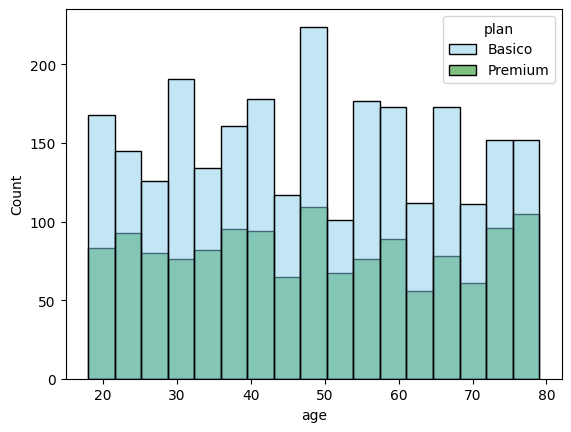

In [29]:


# Histograma para visualizar la edad (age)
sns.histplot(
    data=users,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)
plt.show()


💡Insights: 
- Distribución: tenemos una distribución bastante agradablen la que vemos que el pico de gente esta en los 50 años pero en general esta bastante balanceado

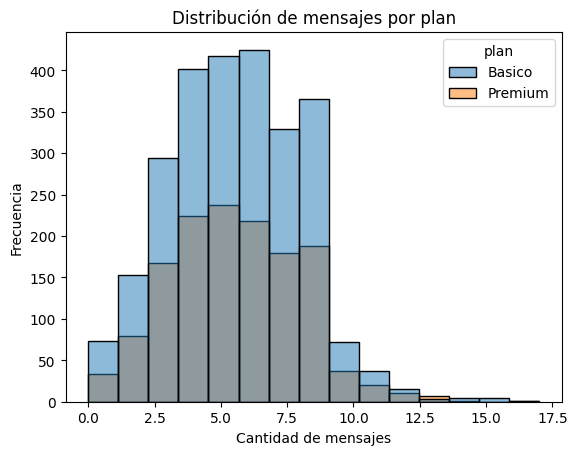

In [30]:
# Histograma para visualizar la cant_mensajes


sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=15
)

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.title('Distribución de mensajes por plan')
plt.show()


💡Insights: 
los datos de la grafica estan un tanto alargados a la derecha pero la diferencia no es tan molesta como para que no se persiban bien los datos

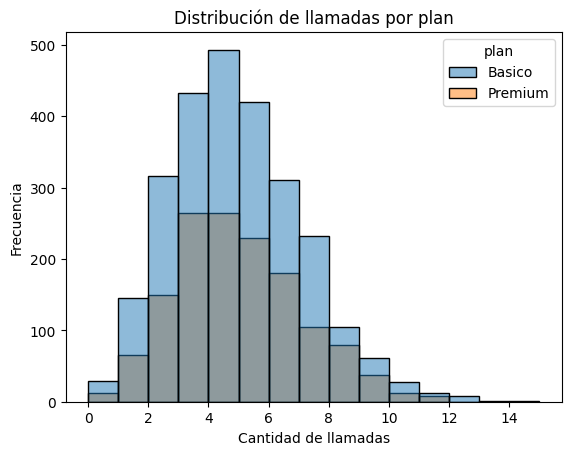

In [31]:

# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=15
)

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.title('Distribución de llamadas por plan')
plt.show()


💡Insights: 
- esta al igual que la anterior esta un poco alargada a la derecha pero sigue siendo legible y no representa una molestia real

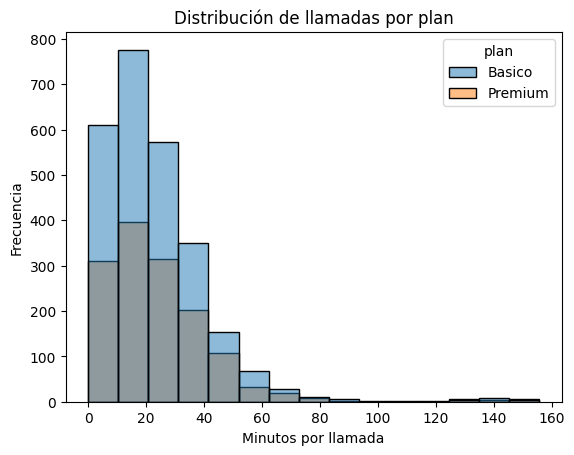

In [32]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=15
)

plt.xlabel('Minutos por llamada')
plt.ylabel('Frecuencia')
plt.title('Distribución de llamadas por plan')
plt.show()


💡Insights: 
- en esta grafica si ya podriamos reducir apartir de los 60 minutos pues ya es una diferencia bastante notable y en caso de la 3 de hecho se puede marcar como que el resto de usuarios tienen un tiempo mayo de llamada

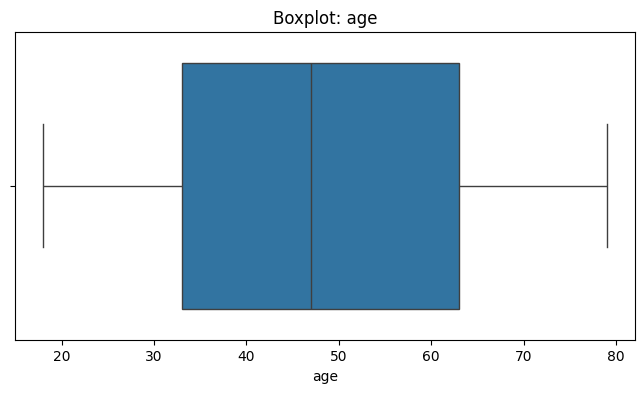

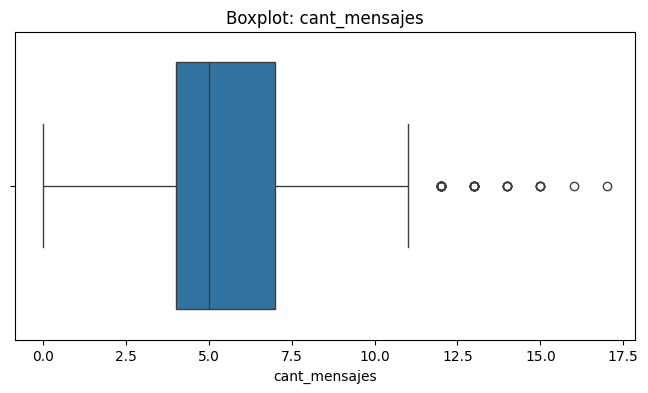

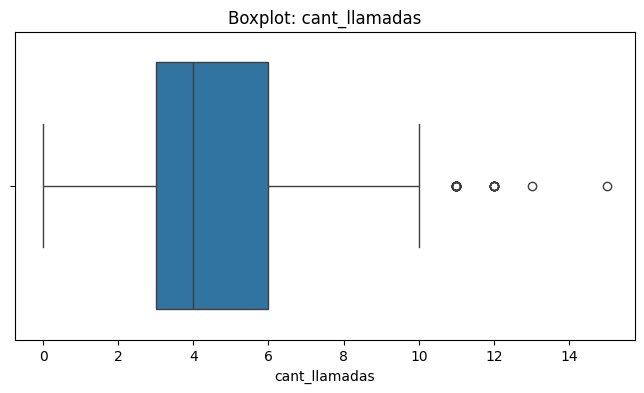

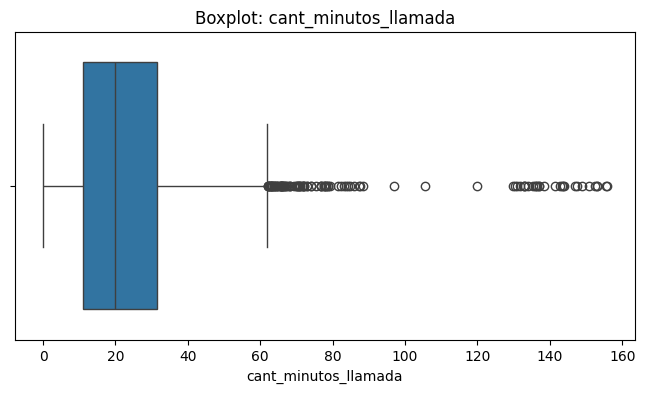

In [33]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


💡Insights: 
- Age: no contamos con outliers es un tabla bien distribuida
- cant_mensajes: contamos con unos pocos outliers los cuales no deberia suponer un problema real solo podriamos eliminarlos o marcarlos como alta duración
- cant_llamadas: aqui sucede lo mismo que en cant_mensajes y podriamos hacer los mismo procesos
- cant_minutos_llamada: en esta ya contamos con datos un poco mas separados lo cual puede ser un poco problematico con los informes pero realemnte no representa nada fuera de los habitual

In [34]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(lower)
    print(upper)


-0.5
11.5
-1.5
10.5
-19.322500000000005
61.8575


In [35]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: los podemos mantener o separar como usuarios de mayo consumo de mensajes pero realmente es inecesario los datos no estan tan exagerados
- cant_llamadas: aqui podemos hacer lo mismo pues realmente la grafica no se dispersa para se molesta
- cant_minutos_llamada: aqui tenemos que hacer revisiones pues ya representa un 100% mas de lo que es el cuarto quartile lo que representa una gran separación

In [36]:
# Crear columna grupo_uso
def clasificar_uso(row):
    mensajes = row['cant_mensajes']
    llamadas = row['cant_llamadas']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [37]:
# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [38]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)


In [39]:
# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


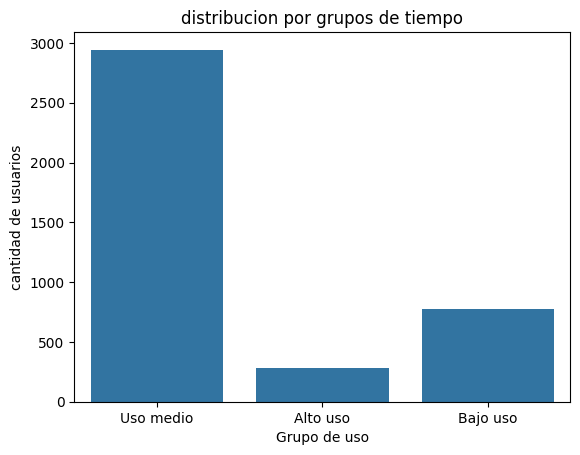

In [40]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('distribucion por grupos de tiempo')
plt.xlabel('Grupo de uso')
plt.ylabel('cantidad de usuarios')
plt.show()


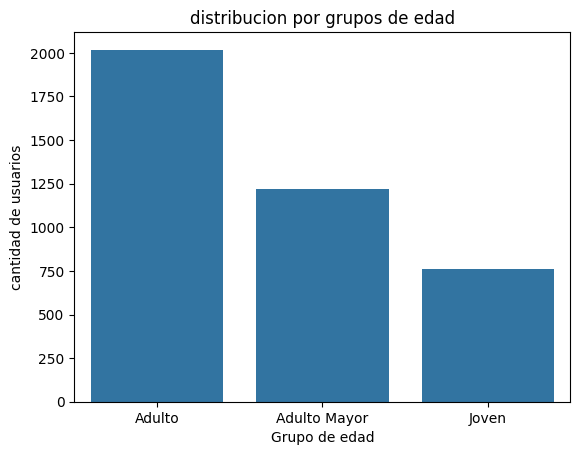

In [41]:

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('distribucion por grupos de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('cantidad de usuarios')
plt.show()


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- contamos con valores invalidos en city
- tenemos fechas que no deberias estar en un data set que estuvo hasta el 2024


🔍 **Segmentos por Edad**
- contamos con valores imposibles como -999


📊 **Segmentos por Nivel de Uso**
- tenemos varios valores un poco fuera de los limites para graficar correctamente pero podemos hacer una grafica distinta por tiempo


➡️ Esto sugiere que tenemos un par de datos invalidos que valen la pena revisar y podemos investigar


💡 **Recomendaciones**
- capar como limite el uso promedio de llamada y hacer 2 presentaciones segun las distribucion

Link a repositorio público del proyecto: `LINK a tu repo aquí`